<a href="https://colab.research.google.com/github/kevin-d-07/buy-the-dip-backtest/blob/main/buy_the_dip_attempt_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install first if needed:
# !pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np

# -----------------------------
# 1. Download SPY price data
# -----------------------------

ticker = "SPY"
start_date = "2000-01-01"
holding_days = 252        # roughly 1 trading year
dip_threshold = -0.05     # -5%

df = yf.download(
    ticker,
    start=start_date,
    auto_adjust=True,
    progress=False
)

# Keep only closing price
df = df[["Close"]].copy()

# In case yfinance returns a MultiIndex
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)


# -----------------------------
# 2. Calculate drawdown
# -----------------------------

# Highest price seen before/current day
df["Previous_High"] = df["Close"].cummax()

# Percentage below previous high
df["Drawdown"] = (
    df["Close"] / df["Previous_High"] - 1
)


# -----------------------------
# 3. Calculate future return
# -----------------------------

# Return after ~1 year
df["Future_Return"] = (
    df["Close"].shift(-holding_days)
    / df["Close"]
    - 1
)


# -----------------------------
# 4. BUY & HOLD benchmark
# -----------------------------

# Every day is treated as a possible entry day
buy_hold = df.dropna(
    subset=["Future_Return"]
).copy()

buy_hold_win_rate = (
    buy_hold["Future_Return"] > 0
).mean()

buy_hold_avg_return = (
    buy_hold["Future_Return"].mean()
)

buy_hold_median_return = (
    buy_hold["Future_Return"].median()
)


# -----------------------------
# 5. BUY THE DIP
# -----------------------------

dip_entries = df[
    df["Drawdown"] <= dip_threshold
].dropna(
    subset=["Future_Return"]
).copy()

dip_win_rate = (
    dip_entries["Future_Return"] > 0
).mean()

dip_avg_return = (
    dip_entries["Future_Return"].mean()
)

dip_median_return = (
    dip_entries["Future_Return"].median()
)


# -----------------------------
# 6. Print results
# -----------------------------

print("BUY & HOLD / RANDOM ENTRY")
print("--------------------------")
print(
    f"Number of observations: {len(buy_hold)}"
)
print(
    f"Win rate: {buy_hold_win_rate:.2%}"
)
print(
    f"Average 1-year return: {buy_hold_avg_return:.2%}"
)
print(
    f"Median 1-year return: {buy_hold_median_return:.2%}"
)


print("\nBUY THE DIP")
print("-----------")
print(
    f"Dip threshold: {dip_threshold:.0%}"
)
print(
    f"Number of dip observations: {len(dip_entries)}"
)
print(
    f"Win rate: {dip_win_rate:.2%}"
)
print(
    f"Average 1-year return: {dip_avg_return:.2%}"
)
print(
    f"Median 1-year return: {dip_median_return:.2%}"
)

BUY & HOLD / RANDOM ENTRY
--------------------------
Number of observations: 6461
Win rate: 77.53%
Average 1-year return: 9.80%
Median 1-year return: 13.09%

BUY THE DIP
-----------
Dip threshold: -5%
Number of dip observations: 3524
Win rate: 77.19%
Average 1-year return: 9.66%
Median 1-year return: 12.21%


Finding:
The initial test showed that buying whenever SPY was at least 5% below its previous high did not outperform a random entry over a one-year holding period. The win rate and average return were very similar, suggesting that a shallow 5% dip alone was not enough to create a clear advantage.

In [2]:
# ============================================
# BUY THE DIP BACKTEST
# SPY: Random Entry vs Dip Buying
# ============================================

# Run this once if yfinance is not installed:
# !pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np


# ============================================
# 1. SETTINGS
# ============================================

ticker = "SPY"

start_date = "2000-01-01"

# Approximate number of trading days in one year
holding_days = 252

# Dip levels we want to test
dip_thresholds = [
    -0.05,   # -5%
    -0.10,   # -10%
    -0.15,   # -15%
    -0.20    # -20%
]


# ============================================
# 2. DOWNLOAD PRICE DATA
# ============================================

df = yf.download(
    ticker,
    start=start_date,
    auto_adjust=True,
    progress=False
)

# Keep only closing price
df = df[["Close"]].copy()

# Fix yfinance MultiIndex if necessary
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)


print("Data downloaded successfully.")
print(f"Number of trading days: {len(df)}")
print()


# ============================================
# 3. CALCULATE DRAWDOWN
# ============================================

# Highest price reached up to each date
df["Previous_High"] = df["Close"].cummax()

# Drawdown from previous high
df["Drawdown"] = (
    df["Close"] / df["Previous_High"]
) - 1


# Example:
#
# Previous high = $500
# Current price = $450
#
# Drawdown = 450 / 500 - 1
#          = -0.10
#          = -10%


# ============================================
# 4. CALCULATE 1-YEAR FUTURE RETURN
# ============================================

df["Future_Return"] = (
    df["Close"].shift(-holding_days)
    / df["Close"]
    - 1
)


# ============================================
# 5. RANDOM ENTRY / BUY & HOLD BENCHMARK
# ============================================

# Treat every available day as a potential entry
benchmark = df.dropna(
    subset=["Future_Return"]
).copy()


benchmark_win_rate = (
    benchmark["Future_Return"] > 0
).mean()

benchmark_avg_return = (
    benchmark["Future_Return"].mean()
)

benchmark_median_return = (
    benchmark["Future_Return"].median()
)


# ============================================
# 6. STORE RESULTS
# ============================================

results = []


# Add benchmark first
results.append({
    "Strategy": "Random Entry",
    "Threshold": "N/A",
    "Number of Events": len(benchmark),
    "Win Rate": benchmark_win_rate,
    "Average 1Y Return": benchmark_avg_return,
    "Median 1Y Return": benchmark_median_return
})


# ============================================
# 7. TEST BUY-THE-DIP THRESHOLDS
# ============================================

for threshold in dip_thresholds:

    # True whenever market is below threshold
    dip = df["Drawdown"] <= threshold


    # Only count FIRST day market crosses threshold
    #
    # Example:
    #
    # -4%   False
    # -5.2% True   <-- count this
    # -6%   True   <-- don't count again
    # -8%   True   <-- don't count again
    #
    new_dip = (
        dip &
        ~dip.shift(1, fill_value=False)
    )


    # Get only valid dip entry dates
    entries = df[
        new_dip
    ].dropna(
        subset=["Future_Return"]
    ).copy()


    # Calculate metrics
    if len(entries) > 0:

        win_rate = (
            entries["Future_Return"] > 0
        ).mean()

        avg_return = (
            entries["Future_Return"].mean()
        )

        median_return = (
            entries["Future_Return"].median()
        )

    else:

        win_rate = np.nan
        avg_return = np.nan
        median_return = np.nan


    # Save results
    results.append({
        "Strategy": "Buy the Dip",
        "Threshold": f"{threshold:.0%}",
        "Number of Events": len(entries),
        "Win Rate": win_rate,
        "Average 1Y Return": avg_return,
        "Median 1Y Return": median_return
    })


# ============================================
# 8. CREATE RESULTS TABLE
# ============================================

results_df = pd.DataFrame(results)


# Format percentages nicely
display_df = results_df.copy()

display_df["Win Rate"] = (
    display_df["Win Rate"]
    .map(lambda x: f"{x:.2%}")
)

display_df["Average 1Y Return"] = (
    display_df["Average 1Y Return"]
    .map(lambda x: f"{x:.2%}")
)

display_df["Median 1Y Return"] = (
    display_df["Median 1Y Return"]
    .map(lambda x: f"{x:.2%}")
)


# ============================================
# 9. PRINT RESULTS
# ============================================

print("=" * 70)
print("BUY THE DIP BACKTEST RESULTS")
print("=" * 70)

print()

print(display_df.to_string(index=False))


# ============================================
# 10. SHOW DIP ENTRY DATES
# ============================================

print()
print("=" * 70)
print("EXAMPLE: -10% DIP ENTRY DATES")
print("=" * 70)

threshold = -0.10

dip = df["Drawdown"] <= threshold

new_dip = (
    dip &
    ~dip.shift(1, fill_value=False)
)

dip_dates = df[
    new_dip
][
    [
        "Close",
        "Previous_High",
        "Drawdown",
        "Future_Return"
    ]
].copy()


# Convert percentages for easier reading
dip_dates["Drawdown"] = (
    dip_dates["Drawdown"] * 100
)

dip_dates["Future_Return"] = (
    dip_dates["Future_Return"] * 100
)


# Rename columns
dip_dates = dip_dates.rename(
    columns={
        "Close": "Entry Price",
        "Previous_High": "Previous High",
        "Drawdown": "Drawdown %",
        "Future_Return": "1Y Return %"
    }
)


print(dip_dates.tail(20))

Data downloaded successfully.
Number of trading days: 6713

BUY THE DIP BACKTEST RESULTS

    Strategy Threshold  Number of Events Win Rate Average 1Y Return Median 1Y Return
Random Entry       N/A              6461   77.53%             9.80%           13.09%
 Buy the Dip       -5%                86   55.81%             3.76%            5.52%
 Buy the Dip      -10%                61   62.30%             5.16%            8.09%
 Buy the Dip      -15%                45   75.56%            13.34%           16.77%
 Buy the Dip      -20%                26   65.38%             7.34%           16.56%

EXAMPLE: -10% DIP ENTRY DATES
Price       Entry Price  Previous High  Drawdown %  1Y Return %
Date                                                           
2016-01-15   158.334778     177.243942  -10.668440    23.054397
2016-01-25   158.191391     177.243942  -10.749338    23.900847
2016-01-27   158.604507     177.243942  -10.516261    24.517455
2016-02-05   158.452728     177.243942  -10.60189

Finding:
When different drawdown levels were tested, deeper dips generally produced stronger forward returns than shallow dips. The −15% threshold performed best in this sample, with a higher average and median one-year return than random entry, although its win rate was slightly lower. This suggests that deeper corrections may provide better entry prices, but not necessarily a higher probability of making a profit.

Data downloaded successfully.
Trading days: 6713

STRATEGY COMPARISON
          Strategy Final Value Total Return  CAGR Max Drawdown Sharpe Ratio
        Buy & Hold  $83,865.55      738.66% 8.29%      -55.19%         0.30
      12-Month DCA  $84,374.55      743.75% 8.32%      -55.19%         0.31
Staged Buy the Dip  $88,012.12      780.12% 8.49%      -55.19%         0.31

BUY-THE-DIP TRADE LOG
        Date Dip Level      Price Drawdown  Amount Invested  Shares Bought  \
0 2000-01-06       -5%  86.315689   -5.29%           2000.0      23.170759   
1 2000-01-28       -5%  85.140762   -7.57%           2000.0      23.490511   
2 2000-02-11       -5%  86.903122   -5.65%           2000.0      23.014133   
3 2000-04-13       -5%  90.618378   -6.06%           2000.0      22.070578   
4 2000-04-14      -10%  85.435699  -11.44%           2000.0      23.409418   

   Cash Remaining  
0          8000.0  
1          6000.0  
2          4000.0  
3          2000.0  
4             0.0  


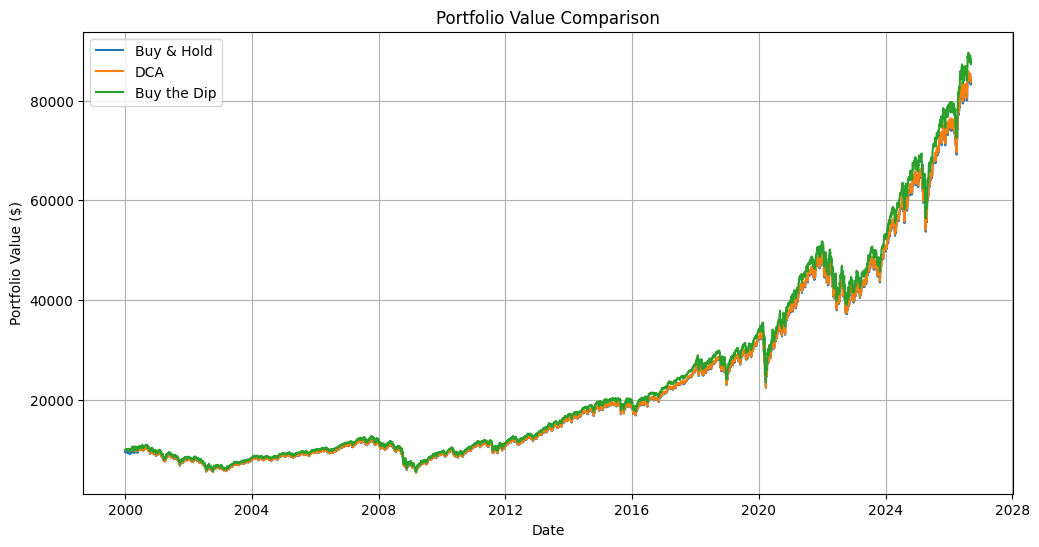

In [3]:
# ============================================
# BUY THE DIP PORTFOLIO BACKTEST
# Compare:
# 1. Buy & Hold
# 2. Monthly DCA
# 3. Staged Buy-the-Dip
# ============================================

# Run once if needed:
# !pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np


# ============================================
# 1. SETTINGS
# ============================================

ticker = "SPY"
start_date = "2000-01-01"

initial_cash = 10000

# Staged dip levels and how much of ORIGINAL cash
# to deploy at each level
dip_levels = {
    -0.05: 0.20,   # invest 20% at -5%
    -0.10: 0.25,   # invest 25% at -10%
    -0.15: 0.25,   # invest 25% at -15%
    -0.20: 0.30    # invest 30% at -20%
}

# Reset the correction when the market
# recovers to within 2% of the previous high
reset_level = -0.02

# Approximate risk-free rate
risk_free_rate = 0.04


# ============================================
# 2. DOWNLOAD DATA
# ============================================

df = yf.download(
    ticker,
    start=start_date,
    auto_adjust=True,
    progress=False
)

df = df[["Close"]].copy()

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df.dropna()

print("Data downloaded successfully.")
print(f"Trading days: {len(df)}")


# ============================================
# 3. CALCULATE DRAWDOWN
# ============================================

df["Previous_High"] = df["Close"].cummax()

df["Drawdown"] = (
    df["Close"] / df["Previous_High"]
) - 1


# ============================================
# 4. HELPER FUNCTIONS
# ============================================

def calculate_max_drawdown(portfolio_series):
    """
    Calculate maximum drawdown of portfolio value.
    """

    running_max = portfolio_series.cummax()

    drawdown = (
        portfolio_series / running_max
    ) - 1

    return drawdown.min()


def calculate_cagr(portfolio_series):
    """
    Compound annual growth rate.
    """

    start_value = portfolio_series.iloc[0]
    end_value = portfolio_series.iloc[-1]

    days = (
        portfolio_series.index[-1]
        - portfolio_series.index[0]
    ).days

    years = days / 365.25

    cagr = (
        end_value / start_value
    ) ** (1 / years) - 1

    return cagr


def calculate_sharpe(portfolio_series):
    """
    Annualised Sharpe ratio.
    """

    daily_returns = (
        portfolio_series.pct_change()
        .dropna()
    )

    daily_rf = (
        risk_free_rate / 252
    )

    excess_returns = (
        daily_returns - daily_rf
    )

    sharpe = (
        excess_returns.mean()
        / excess_returns.std()
    ) * np.sqrt(252)

    return sharpe


# ============================================
# 5. BUY & HOLD
# ============================================

first_price = df["Close"].iloc[0]

buy_hold_shares = (
    initial_cash / first_price
)

df["Buy_Hold_Value"] = (
    buy_hold_shares
    * df["Close"]
)


# ============================================
# 6. MONTHLY DCA
# ============================================

# Spread the initial $10,000 evenly
# over 12 months

monthly_investment = (
    initial_cash / 12
)

dca_cash = initial_cash
dca_shares = 0

dca_values = []

current_month = None


for date, row in df.iterrows():

    price = float(row["Close"])

    month = (
        date.year,
        date.month
    )

    # Invest once at beginning of each month
    if (
        month != current_month
        and dca_cash > 0
    ):

        amount = min(
            monthly_investment,
            dca_cash
        )

        shares_bought = (
            amount / price
        )

        dca_shares += shares_bought
        dca_cash -= amount

        current_month = month


    portfolio_value = (
        dca_cash
        + dca_shares * price
    )

    dca_values.append(
        portfolio_value
    )


df["DCA_Value"] = dca_values


# ============================================
# 7. BUY THE DIP STRATEGY
# ============================================

dip_cash = initial_cash
dip_shares = 0

dip_values = []

# Track which dip levels have already been bought
triggered_levels = {
    level: False
    for level in dip_levels
}

trade_log = []


for date, row in df.iterrows():

    price = float(row["Close"])

    drawdown = float(
        row["Drawdown"]
    )


    # ----------------------------------------
    # RESET RULE
    # ----------------------------------------

    # If market recovers close to all-time high,
    # allow future dip levels to trigger again
    if drawdown >= reset_level:

        triggered_levels = {
            level: False
            for level in dip_levels
        }


    # ----------------------------------------
    # CHECK DIP LEVELS
    # ----------------------------------------

    for level, allocation in sorted(
        dip_levels.items(),
        reverse=True
    ):

        if (
            drawdown <= level
            and not triggered_levels[level]
            and dip_cash > 0
        ):

            amount_to_invest = (
                initial_cash
                * allocation
            )

            amount_to_invest = min(
                amount_to_invest,
                dip_cash
            )

            shares_bought = (
                amount_to_invest
                / price
            )

            dip_shares += shares_bought
            dip_cash -= amount_to_invest

            triggered_levels[level] = True


            trade_log.append({
                "Date": date,
                "Dip Level": level,
                "Price": price,
                "Drawdown": drawdown,
                "Amount Invested": amount_to_invest,
                "Shares Bought": shares_bought,
                "Cash Remaining": dip_cash
            })


    portfolio_value = (
        dip_cash
        + dip_shares * price
    )

    dip_values.append(
        portfolio_value
    )


df["Buy_Dip_Value"] = dip_values


# ============================================
# 8. RESULTS FUNCTION
# ============================================

def strategy_metrics(
    name,
    portfolio_series
):

    return {
        "Strategy": name,

        "Final Value":
            portfolio_series.iloc[-1],

        "Total Return":
            portfolio_series.iloc[-1]
            / portfolio_series.iloc[0]
            - 1,

        "CAGR":
            calculate_cagr(
                portfolio_series
            ),

        "Max Drawdown":
            calculate_max_drawdown(
                portfolio_series
            ),

        "Sharpe Ratio":
            calculate_sharpe(
                portfolio_series
            )
    }


# ============================================
# 9. CREATE RESULTS TABLE
# ============================================

results = []

results.append(
    strategy_metrics(
        "Buy & Hold",
        df["Buy_Hold_Value"]
    )
)

results.append(
    strategy_metrics(
        "12-Month DCA",
        df["DCA_Value"]
    )
)

results.append(
    strategy_metrics(
        "Staged Buy the Dip",
        df["Buy_Dip_Value"]
    )
)


results_df = pd.DataFrame(
    results
)


# ============================================
# 10. FORMAT RESULTS
# ============================================

display_results = (
    results_df.copy()
)

display_results[
    "Final Value"
] = display_results[
    "Final Value"
].map(
    lambda x: f"${x:,.2f}"
)

display_results[
    "Total Return"
] = display_results[
    "Total Return"
].map(
    lambda x: f"{x:.2%}"
)

display_results[
    "CAGR"
] = display_results[
    "CAGR"
].map(
    lambda x: f"{x:.2%}"
)

display_results[
    "Max Drawdown"
] = display_results[
    "Max Drawdown"
].map(
    lambda x: f"{x:.2%}"
)

display_results[
    "Sharpe Ratio"
] = display_results[
    "Sharpe Ratio"
].map(
    lambda x: f"{x:.2f}"
)


print()
print("=" * 70)
print("STRATEGY COMPARISON")
print("=" * 70)

print(
    display_results.to_string(
        index=False
    )
)


# ============================================
# 11. TRADE LOG
# ============================================

trade_log_df = pd.DataFrame(
    trade_log
)


if not trade_log_df.empty:

    trade_log_df[
        "Dip Level"
    ] = trade_log_df[
        "Dip Level"
    ].map(
        lambda x: f"{x:.0%}"
    )

    trade_log_df[
        "Drawdown"
    ] = trade_log_df[
        "Drawdown"
    ].map(
        lambda x: f"{x:.2%}"
    )


print()
print("=" * 70)
print("BUY-THE-DIP TRADE LOG")
print("=" * 70)

print(
    trade_log_df.tail(30)
)


# ============================================
# 12. OPTIONAL: PLOT PORTFOLIO VALUES
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    df.index,
    df["Buy_Hold_Value"],
    label="Buy & Hold"
)

plt.plot(
    df.index,
    df["DCA_Value"],
    label="DCA"
)

plt.plot(
    df.index,
    df["Buy_Dip_Value"],
    label="Buy the Dip"
)

plt.title(
    "Portfolio Value Comparison"
)

plt.xlabel("Date")

plt.ylabel(
    "Portfolio Value ($)"
)

plt.legend()

plt.grid()

plt.show()

Finding:
When the strategies were tested as actual portfolios using the same starting capital, Buy & Hold, DCA, and staged Buy-the-Dip produced broadly similar long-term results. The Buy-the-Dip strategy achieved a slightly better entry price in some periods, but the overall difference was relatively small because all three strategies eventually became heavily invested in SPY and were exposed to the same market movements.

Overall conclusion: The results suggest that simply buying small dips does not consistently outperform staying invested. Deeper drawdowns may offer more attractive entry points, but the benefit becomes much smaller when tested within a realistic long-term portfolio. This highlights the importance of comparing trading signals against simple benchmarks such as Buy & Hold and DCA rather than evaluating them in isolation.